# 03 EDA

**Project:** F1 Driver vs Strategy

**Author:** Ayema Qureshi

**Stage:** Silver layer (feature-enriched tables in, insights and visualizations out)

## Purpose
This notebook explores the cleaned and feature-engineered data from notebooks 01 and 02 to answer the research question: does winning in Formula 1 come down to the driver, the team strategy, or both, and has that balance shifted across four regulatory eras? Five charts and two verification checks build the story piece by piece, each connecting back to a specific supporting question from the project brief.

## Inputs
Feature tables from `data/processed/`: results, team_season, avg_pit_stop. One ad-hoc read of `circuits.csv` from `data/raw/` for the circuit-level verification check only.

## Outputs
Five PNG visualizations written to `visualizations/`: chart1_grid_vs_finish, chart2_position_change_by_era, chart3_teammate_gap_by_era, chart4_avg_pit_stop_trend, chart5_pit_stop_vs_constructor_points.

## EDA Steps
1. Load feature-enriched tables from `data/processed/` and recast nullable Int64 dtypes lost in the CSV round-trip
2. Filter to `results_finished_gridded` (5,337 rows): excludes 1,039 DNFs and 85 pit lane starts with 25-row overlap
3. Chart 1: grid vs finish scatter colored by era, Pearson r annotation per era, diagonal reference line
4. Chart 2: position_change violin by era with inner boxplot, tests distribution shape for statistical validity
5. Chart 3: teammate_gap boxplot by era on team_season, era added via pd.cut, plus year-level drill-down verification
6. Chart 4: avg pit stop line chart by season with era background shading
7. Chart 5: avg pit stop vs constructor points scatter colored by era, team_season merged with avg_pit_stop
8. Verification Check 1: DNF rate by era, confirms and refines the 17% to 11% claim from Chart 1 caveats
9. Verification Check 2: grid-finish correlation by circuit, tests circuit skew on Chart 1, range 0.67 to 0.83

## The Five Charts at a Glance

**1. Grid Position vs Finishing Position** (baseline, race grain)
Does where you start predict where you finish? Pearson r sits around 0.75 across all four eras. Grid position is a meaningful predictor but never the whole story. Does not assign cause.

**2. Position Change Distribution by Era** (driver skill, race grain)
When drivers move, how much do they move? Medians are nearly identical across all four eras (1.0, 1.0, 0.5, 1.0). Raw race movement did not change across eras. Closes a door for the research question. Also validates symmetric distribution shape for t-tests.

**3. Teammate Gap by Era** (driver skill, strongest proxy, team-season grain)
Same car, two drivers. Medians: 15, 28, 9, 22 points. Mercedes era had the biggest typical gap. 2021 had the smallest median but the highest mean (52.5) and std (73), driven by two outliers. This is why the project reports medians over means for skewed data.

**4. Average Pit Stop Duration by Season** (team strategy, season grain)
Has pit stop execution gotten faster over time? The 2022-2024 era sits consistently lower than most of the blue era. Pit stops got faster and stayed faster in the modern era. 2020 spike likely reflects COVID season disruptions.

**5. Avg Pit Stop vs Constructor Points** (stakeholder-facing, team-season grain)
Do teams with faster pit stops finish higher in the championship? No team with slow pit stops above 26 seconds scored significant points in any era. Association is consistent across all four eras. Does not prove causation but consistency across two regulatory regimes makes the pattern hard to dismiss.

## Key Decisions
1. **Documentation strategy:** each chart has a short summary block above it and a detailed block below it. Short version communicates the finding for a reviewer scanning the notebook. Detailed version defends the analysis for the technical reviewer. Both are needed for an industrial portfolio project because employers read at different depths.
2. **Era tells the story, drill-downs verify and enrich it.** Year-level, circuit-level, or team-level breakdowns validate era-level findings without abandoning the research question. Not scope creep, rigor.
3. **Correlation is not causation.** Every chart notes what it does NOT prove, not just what it shows.
4. **Medians beat means for skewed data.** Chart 3 drill-down is the canonical example: 2021 median gap = 9, mean = 52.5.
5. **Association across all four eras and two regulatory regimes is harder to dismiss than a single-season pattern.** Consistency is a form of evidence.
6. **No imputation.** Same principle carried from notebooks 01 and 02. Nulls sit out of the math.
7. **Colorblind-friendly palette (Wong 2011).** Same era colors used across every chart for visual consistency.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Setup

Loaded `results` from `data/processed/` (feature-enriched table with
`position_change`, `era`, and `year` already built in notebook 02).
Recast `position` to nullable `Int64` to restore dtype lost in CSV
round-trip.

Filtered to `results_finished_gridded` (5,337 rows): excludes 1,039
DNF rows where `position` is null and 85 pit lane starts where
`grid == 0`. Overlap of 25 rows that were both pit lane starters and
DNFs accounts for the difference from the naive sum of 1,124. Original
`results` (6,436 rows) preserved for charts that need the full picture.


In [2]:
# Load results from data/processed (has position_change and era already built)
results = pd.read_csv('../data/processed/results.csv')
team_season = pd.read_csv('../data/processed/team_season.csv')
avg_pit_stop = pd.read_csv('../data/processed/avg_pit_stop.csv')

In [3]:
# recast position to Int64
results['position'] = results['position'].astype('Int64')

In [4]:
# get rid of the rows where position is NaN (DNF) and Pit lane starts out (grid == 0) get rid of them 
results_finished_gridded = results[(results['position'].notna()) & (results['grid'] != 0)].copy()

## Chart 1: Grid Position vs Finishing Position by Era

**Purpose:** Does where you start predict where you finish?

**What it shows:** Each dot is one driver in one race. The
dashed line is "finished exactly where you started." Dots
below the line gained places, dots above lost places.

**Key finding:** Pearson r sits around 0.75 across all four
eras. Grid position is a meaningful predictor but never
the whole story. The relationship barely changed across
15 years of F1.

**Important:** This chart does not assign cause. A strong
grid-to-finish relationship could mean car dominance,
driver consistency, or limited overtaking on modern tracks.
It sets the baseline for everything that follows.

**Caveats:** DNFs excluded (1,039 rows). 2021 is one season
only (440 rows), treat its cloud as a single data point.


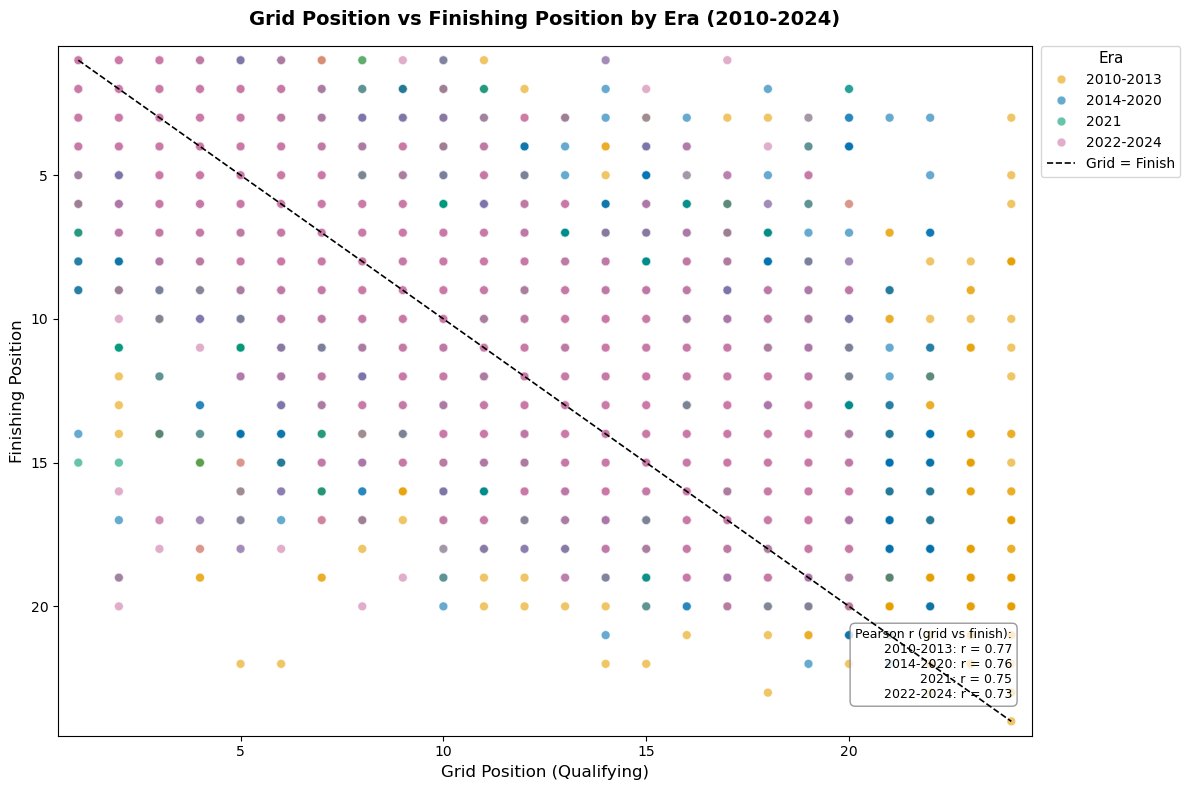

In [5]:
# Colorblind-friendly palette (Wong 2011, widely used in academic publishing)
era_palette = {
    '2010-2013': '#E69F00',   # orange
    '2014-2020': '#0072B2',   # blue
    '2021':      '#009E73',   # green
    '2022-2024': '#CC79A7'    # pink/mauve
}

fig, ax = plt.subplots(figsize=(12, 8))

sns.scatterplot(
    data=results_finished_gridded,
    x='grid',
    y='position',
    hue='era',
    palette=era_palette,
    alpha=0.6,
    s=40,
    ax=ax
)

# Diagonal reference line: grid = finish (perfect prediction)
ax.plot([1, 24], [1, 24], color='black', linewidth=1.2, 
        linestyle='--', label='Grid = Finish', zorder=5)

# Invert y-axis: P1 at top
ax.invert_yaxis()

# Axis limits: F1 has max 24 starters in this window
ax.set_xlim(0.5, 24.5)
ax.set_ylim(24.5, 0.5)

# Correlation annotation per era
eras = ['2010-2013', '2014-2020', '2021', '2022-2024']
colors = ['#E69F00', '#0072B2', '#009E73', '#CC79A7']
annotation_lines = []

for era, color in zip(eras, colors):
    subset = results_finished_gridded[results_finished_gridded['era'] == era]
    corr = subset['grid'].corr(subset['position'])
    annotation_lines.append(f"{era}: r = {corr:.2f}")

annotation_text = "Pearson r (grid vs finish):\n" + "\n".join(annotation_lines)

ax.text(
    0.98, 0.05,
    annotation_text,
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment='bottom',
    horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='grey', alpha=0.8)
)

ax.set_title(
    'Grid Position vs Finishing Position by Era (2010-2024)',
    fontsize=14,
    fontweight='bold',
    pad=15
)
ax.set_xlabel('Grid Position (Qualifying)', fontsize=12)
ax.set_ylabel('Finishing Position', fontsize=12)

# Legend outside the plot on the right
ax.legend(
    title='Era',
    title_fontsize=11,
    fontsize=10,
    loc='upper left',
    bbox_to_anchor=(1.01, 1),
    borderaxespad=0
)

plt.tight_layout()
plt.savefig('../visualizations/chart1_grid_vs_finish.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 1: Grid Position vs Finishing Position by Era (2010-2024)

### What this chart is asking
Does where you start predict where you finish?
This is the first question we need to answer before anything else.
If starting position completely determines the result, the car and
qualifying pace did all the work. If drivers are regularly finishing
far away from where they started, something else is happening during
the race, whether that is driver skill, team strategy, or both.

### How to read this chart
Every dot is one driver in one race.
- The bottom axis (left to right) shows where they started: P1
on the left, P24 on the right.
- The left axis (top to bottom) shows where they finished: P1
at the top, P24 at the bottom.
- The black dashed line is the "nothing changed" reference line.
A dot sitting exactly on it means that driver started and finished
in the same position.
- Dots above the line: the driver finished worse than they started.
They lost places during the race.
- Dots below the line: the driver finished better than they started.
They gained places during the race.

### What Pearson r means in plain English
The numbers in the bottom right corner (r = 0.77, 0.76, 0.75, 0.73)
measure how strongly grid position predicted finishing position in
each era. Think of it like a score from 0 to 1:
- 1.0 would mean every driver finished exactly where they started,
every single race.
- 0.0 would mean starting position told you absolutely nothing
about where someone would finish.
- Our numbers sit around 0.75, which means grid position is a
meaningful predictor but nowhere near the whole story.
There is real movement happening during races across all four eras.

### What this chart is actually telling us
Grid position consistently predicted finishing position across all
15 seasons, but it never locked the result in completely. The wide
scatter of dots away from the diagonal line shows that positions
changed regularly during races. Drivers who started near the back
sometimes finished near the front, and drivers who started up front
sometimes fell back.

Importantly, the relationship barely changed across eras. The r value
only dropped from 0.77 to 0.73 over 15 years. This tells us the
baseline grip of starting position on race outcomes has been
remarkably stable, even as regulations, cars, and dominant teams
changed dramatically.

### What this chart does NOT tell us
A strong grid-to-finish relationship does not automatically mean
the car did all the work. It could mean the driver who qualified
well also races well. It could mean modern circuits make overtaking
difficult. This chart establishes the baseline. The teammate gap
and position change charts that follow will start to separate
what is car, what is driver, and what is strategy.

### Important caveats
- DNFs are excluded (1,039 rows). DNF rates stayed at ~17% for 2010-2020, then dropped to ~11-12% from 2021 onward.
- 2021 is one season only (440 rows). Its color cloud is smaller
than the others, not because less happened that year, but because
there were simply fewer races to draw from. Treat 2021 visually
as a single data point, not a full era pattern.
- The four eras have very different numbers of races behind them
(4 seasons, 7 seasons, 1 season, 3 seasons). The visual density
of each color is not a fair comparison of how often things
happened, just of how many races exist in each era.

### What comes next
This chart sets up two follow-up questions:
- Who is actually gaining those positions during races?
(Chart 2: position change by era)
- Is the gap between teammates on the same car getting bigger
or smaller across eras?
(Chart 3: teammate gap by era)

## Chart 2: Position Change Distribution by Era

**Purpose:** When drivers move during a race, how much do
they move? Has that changed across eras?

**What it shows:** Each violin is one era. The fat middle
is where most drivers landed. The tails are the rare hero
drives and disasters. The white dot is the median.

**Key finding:** Medians are nearly identical across all
four eras (1.0, 1.0, 0.5, 1.0). Raw race movement did
not change across eras. This closes a door: the driver
vs strategy story does not live in position change.

**Bonus:** The symmetric shape validates that t-tests are
appropriate for era comparisons in statistical testing.

**Caveats:** Same filtered frame as Chart 1. 2021 violin
is smaller because it is one season of data, not because
less movement happened.
nto the
t-tests we run after the five charts are done.

/var/folders/v2/9k8drrwj5h39kpr935vvx6j80000gn/T/ipykernel_92183/305575400.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


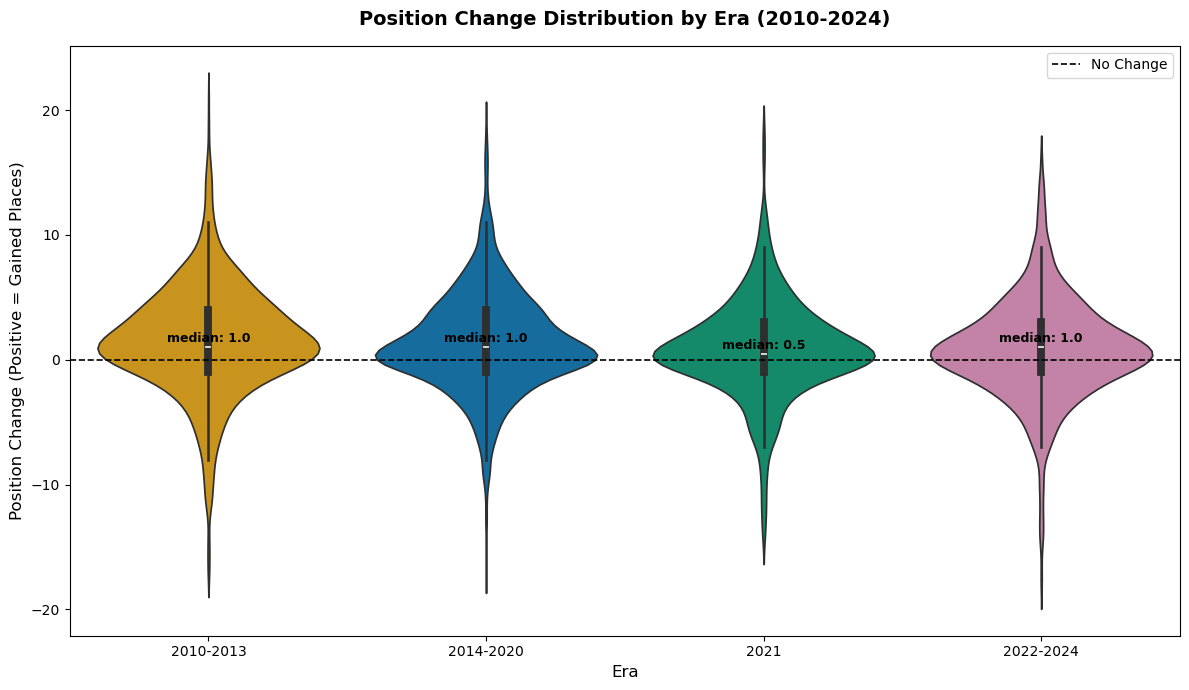

In [6]:
fig, ax = plt.subplots(figsize=(12, 7))

sns.violinplot(
    data=results_finished_gridded,
    x='era',
    y='position_change',
    palette=era_palette,
    inner='box',
    ax=ax
)

# Reference line at zero: no position change
ax.axhline(y=0, color='black', linewidth=1.2, linestyle='--', label='No Change')

ax.set_title(
    'Position Change Distribution by Era (2010-2024)',
    fontsize=14,
    fontweight='bold',
    pad=15
)
ax.set_xlabel('Era', fontsize=12)
ax.set_ylabel('Position Change (Positive = Gained Places)', fontsize=12)

ax.legend(fontsize=10)

# Median annotation per era
era_order = ['2010-2013', '2014-2020', '2021', '2022-2024']
for i, era in enumerate(era_order):
    median = results_finished_gridded[
        results_finished_gridded['era'] == era
    ]['position_change'].median()
    ax.text(
        i, median + 0.4,
        f'median: {median:.1f}',
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

plt.tight_layout()
plt.savefig('../visualizations/chart2_position_change_by_era.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 2: Position Change Distribution by Era (2010-2024)

### What this chart is asking
Chart 1 showed us that drivers do move around during races.
This chart zooms into that movement and asks: how much do
drivers actually move, and did that change across eras?

### How to read this chart
Imagine asking every driver after their race: did you finish
better or worse than where you started? This chart is 5,337
of those answers, sorted into four piles by era.

- The fat middle part of each shape is where most answers
landed. The wider the shape, the more drivers had that
exact result.
- The skinny tail stretching up is the rare hero drive:
someone started 18th and finished 3rd.
- The skinny tail stretching down is the rare disaster:
someone started 3rd and finished 18th.
- The dashed line at zero means finished exactly where
you started.

### What median 1.0 means
If you lined up every driver's position change from worst
to best, the driver exactly in the middle gained 1 place.
Half of all drivers did better than that, half did worse.
Three eras have a median of 1.0 and 2021 has 0.5. In plain
terms: the typical driver in every era gained about one
place during a race.

### What this chart is telling us
All four piles look almost identical. The typical race in
2012 looked like the typical race in 2023: gain a spot or
two, occasionally a hero drive, occasionally a disaster.

That flatness is the finding. The cars changed completely,
the regulations reset twice, and different teams dominated
each era. Yet how much drivers move during a race stayed
the same. When something stays flat while everything around
it changes, that is information.

### Why this matters for the research question
This chart closes a door. The difference between eras does
NOT live in raw race movement. If driver skill or team
strategy shifted in importance across eras, the evidence
must live somewhere else: in the gap between teammates in
the same car, or in pit stop execution. The next charts go
looking there.

### One more job this chart does
The shapes are roughly symmetric around their middle, with
no wild lopsidedness. That matters because the statistical
tests planned for later (t-tests comparing eras) assume
roughly symmetric data. This chart is the visual evidence
that those tests are valid to run.

### Caveats
- Same filtered data as chart 1: DNFs and pit lane starts
excluded (5,337 rows kept).
- 2021 is one season (440 rows) versus multiple seasons for
every other era. Its shape is drawn from less data, which
is why it looks slightly compressed. Read it carefully,
not as a full era pattern.
- Position change measures where drivers ended up, not how
they got there. A gained place could be an overtake, a
smart pit call, or a rival breaking down. It is a proxy,
not a perfect measure of driver skill.

## Chart 3: Teammate Gap by Era (2010-2024)

### What this chart is asking
Has the points gap between teammates on the same team
gotten bigger or smaller across eras?

Teammate gap is the difference in season points between
the two drivers on the same team. We are looking at
points_high minus points_low per team per season, grouped
by era.

### Why this is the strongest driver proxy in the project
Both drivers have the exact same car. Same engine, same
tires, same pit crew, same strategy resources. So when
one driver consistently scores way more points than their
teammate, the car is no longer the variable. That gap
has to come from the driver.

- A big gap in an era means one driver is doing something
the other simply cannot do in identical machinery. Driver
skill is loud in that era.
- A small gap in an era means both drivers are performing
similarly in the same car. The car is doing most of the
work and the driver on top matters less.

### How a mid-tier stakeholder like Aston Martin uses this
This chart speaks directly to the budget question your
stakeholder is trying to answer: should we invest in a
better driver or better car development and strategy?

If teammate gaps are growing across eras, driver choice
matters more now than ever. Signing a better driver has
a measurable points impact.

If teammate gaps are shrinking, the car is doing more of
the work. The money goes toward development and pit crew
execution instead.

### How to read this chart
Each box is one era. The line in the middle of each box
is the median gap for that era, the most typical points
difference between teammates. The box itself covers the
middle 50% of team seasons. The lines extending out show
the full range. The dots floating outside are outliers,
seasons where one teammate absolutely dominated the other
in identical machinery.

### Caveats
- 159 team-seasons across 4 eras. Smaller dataset than
charts 1 and 2, which is why we chose a boxplot over a
violin. A violin needs more data points to draw a
meaningful shape.
- Sprint points are excluded everywhere in this project.
Grand prix points only, so all four eras are measured on
the same scoring source. 2021 to 2024 season totals will
not match official championship standings.
- Gap measures size only, not direction. A gap of 100
cannot tell you if one driver was exceptional or if their
teammate underperformed. It only tells you the spread
existed.
- Mid-season driver swaps happened in 35 of 159 team
seasons. The top two drivers by races entered were kept
per team season to ensure fair comparison. Points
tiebreaker used for determinism.
- Teammate gap inherits DNF asymmetry. A driver whose
car breaks down repeatedly scores fewer points through
no fault of their own, which inflates the gap artificially
in those team seasons.

In [7]:
team_season['era'] = pd.cut(
    team_season['year'],
    bins=[2009, 2013, 2020, 2021, 2024],
    labels=['2010-2013', '2014-2020', '2021', '2022-2024']
)

In [8]:
team_season.head()

,constructorId,year,points_high,points_low,teammate_gap,era
0,1,2010,240.0,214.0,26.0,2010-2013
1,1,2011,270.0,227.0,43.0,2010-2013
2,1,2012,190.0,188.0,2.0,2010-2013
3,1,2013,73.0,49.0,24.0,2010-2013
4,1,2014,126.0,55.0,71.0,2014-2020


/var/folders/v2/9k8drrwj5h39kpr935vvx6j80000gn/T/ipykernel_92183/2957525887.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


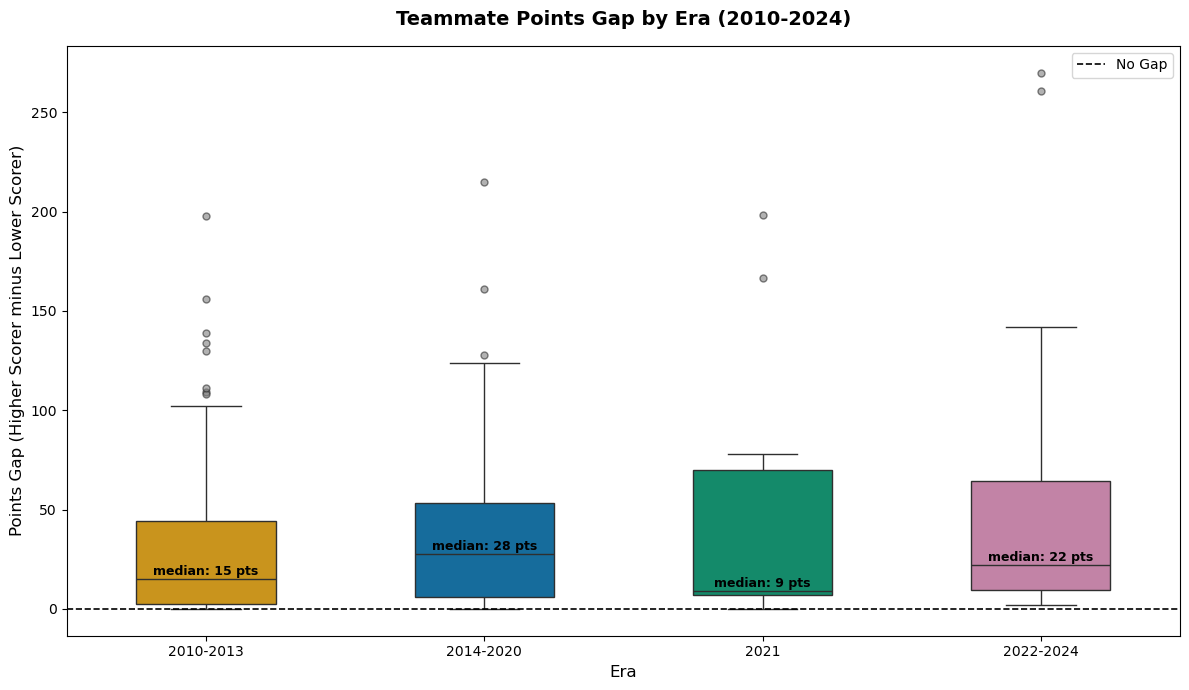

In [9]:
fig, ax = plt.subplots(figsize=(12, 7))

sns.boxplot(
    data=team_season,
    x='era',
    y='teammate_gap',
    palette=era_palette,
    width=0.5,
    flierprops=dict(marker='o', markerfacecolor='grey', 
                    markersize=5, alpha=0.6),
    ax=ax
)

# Reference line at zero: no gap between teammates
ax.axhline(y=0, color='black', linewidth=1.2, 
           linestyle='--', label='No Gap')

ax.set_title(
    'Teammate Points Gap by Era (2010-2024)',
    fontsize=14,
    fontweight='bold',
    pad=15
)
ax.set_xlabel('Era', fontsize=12)
ax.set_ylabel('Points Gap (Higher Scorer minus Lower Scorer)', 
              fontsize=12)

# Median annotation per era
era_order = ['2010-2013', '2014-2020', '2021', '2022-2024']
for i, era in enumerate(era_order):
    median = team_season[
        team_season['era'] == team_season['era']
    ]
    median_val = team_season[
        team_season['era'] == era
    ]['teammate_gap'].median()
    ax.text(
        i, median_val + 2,
        f'median: {median_val:.0f} pts',
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../visualizations/chart3_teammate_gap_by_era.png', 
            dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# group by year and calcualte teammate gap for each year
teammate_gap_stats = team_season.groupby('year')['teammate_gap'].agg(['mean', 'median', 'std']).reset_index()

In [11]:
print(teammate_gap_stats)

    year       mean  median        std
0   2010  33.916667    25.5  39.884967
1   2011  31.416667    12.0  50.516349
2   2012  38.166667    10.0  54.001403
3   2013  45.000000    19.0  63.066631
4   2014  38.727273    37.0  36.902821
5   2015  30.300000    19.0  38.303032
6   2016  24.545455    29.0  19.745195
7   2017  31.400000    22.5  34.069211
8   2018  45.500000    27.5  47.141041
9   2019  48.400000    26.5  63.096399
10  2020  45.700000    46.5  45.043312
11  2021  52.550000     9.0  73.021857
12  2022  40.600000    24.0  44.129104
13  2023  61.600000    19.0  86.093231
14  2024  54.700000    22.0  76.419965


## Chart 3: Teammate Gap by Era (2010-2024)

### What this chart is asking
Has the points gap between teammates on the same team
gotten bigger or smaller across eras?

Teammate gap is the difference in season points between
the two drivers on the same team. Both drivers have the
exact same car, so when one consistently scores more,
the car is no longer the explanation. This is the
strongest driver skill signal in the project.

### How to read this chart
Each box is one era. Inside every box is the story of
how big the gap between teammates typically was.

- The line in the middle of each box is the median: the
most typical gap in that era. Pick any random team from
any random season in that era and this is roughly the
gap you would expect to find.
- The box captures the middle 50% of all team seasons.
- The lines stretching up and down show the full range.
- The grey dots floating above are outliers: seasons
where one driver absolutely dominated their teammate in
identical machinery. These are the loudest driver skill
signals in the entire dataset.
- The dashed line at zero would mean both drivers scored
identical points. No team ever landed exactly there.
There is always some gap, even in the closest eras.

### What the medians say
- 2010-2013: 15 points. Moderate gap during the Vettel
and Red Bull years.
- 2014-2020: 28 points. The biggest typical gap of any
era, during Mercedes dominance.
- 2021: 9 points. The smallest typical gap, in the most
evenly fought season in years.
- 2022-2024: 22 points. The gap grew again as Verstappen
pulled away from Perez in the same Red Bull.

### Drill-down: verifying the era story year by year
Era grouping could hide what is happening inside each
era, so the table below breaks the gap down by individual
year as a robustness check. The check confirmed the era
pattern is real, and it surfaced something the era view
alone could not see.

### The 2021 surprise: small median, huge mean
The year by year table shows 2021 with a median gap of
just 9 points but a mean of 52.5, the highest of any
year, with the largest standard deviation (73).

How can the typical gap be the smallest while the average
gap is the biggest? Outliers. Most teams in 2021 had
nearly equal drivers, which keeps the median tiny. But a
small number of teams had enormous gaps, and those extreme
values drag the mean up while the median stays put. The
two grey dots floating high above the 2021 box in the
chart are exactly those teams. The most likely story:
Verstappen scoring over 300 points in his title fight
while Perez trailed far behind in the same Red Bull.

So the complete, honest 2021 story is: most teams had
nearly equal drivers, but at the very top, one driver was
carrying. The title fight was close between teams while
inside certain garages the gap was enormous.

This is also a live demonstration of why this project
reports medians instead of means for skewed data. The
mean would have told a misleading story about 2021.

### What this means for the stakeholder
If you are a mid-tier constructor deciding where to
invest, this chart says driver choice has a measurable
impact on points. The gap between two drivers in the same
car is not random. In eras where one driver is
significantly better, the team loses points it could have
had. Signing a stronger second driver is not just about
prestige. It shows up in the championship table.

### Caveats
- 159 team-seasons across 4 eras. Smaller dataset than
charts 1 and 2, which is why a boxplot was chosen over a
violin.
- Sprint points are excluded everywhere in this project.
Grand prix points only, so all four eras are measured on
the same scoring source. 2021-2024 totals will not match
official standings.
- Gap measures size only, not direction. A gap of 100
cannot tell you whether one driver was exceptional or
their teammate underperformed.
- Mid-season driver swaps happened in 35 of 159 team
seasons. The top two drivers by races entered were kept,
points tiebreaker, to ensure fair comparison.
- Teammate gap inherits DNF asymmetry. A driver whose car
breaks down repeatedly loses points through no fault of
their own, inflating the gap artificially.
- Era grouping smooths over within-era variation. The
year by year drill-down above addresses this, and a full
year-level analysis is noted as future work.

## Chart 4: Average Pit Stop Duration by Season

**Purpose:** Has pit stop execution gotten faster over
time? Did anything shift when the eras changed?

**What it shows:** The black line is the league-wide
average pit stop duration per season. Lower means faster.
The colored background bands show which era each season
belongs to.

**Key finding:** The 2022-2024 era sits consistently
lower than most of the blue era. Pit stops got faster
and stayed faster in the modern era. The 2020 spike
likely reflects COVID season disruptions.

**Stakeholder takeaway:** When the whole field gets
faster, the gap between fastest and slowest crews becomes
the differentiator. Pit crew investment matters more
in the modern era, not less.

**Caveats:** 2010 excluded (data starts 2011). Duration
is full pit lane transit, not just the tire change.
Cross-season comparisons partly reflect calendar changes.


In [12]:
avg_pit_stop['era'] = pd.cut(
    avg_pit_stop['year'],
    bins=[2009, 2013, 2020, 2021, 2024],
    labels=['2010-2013', '2014-2020', '2021', '2022-2024']
)

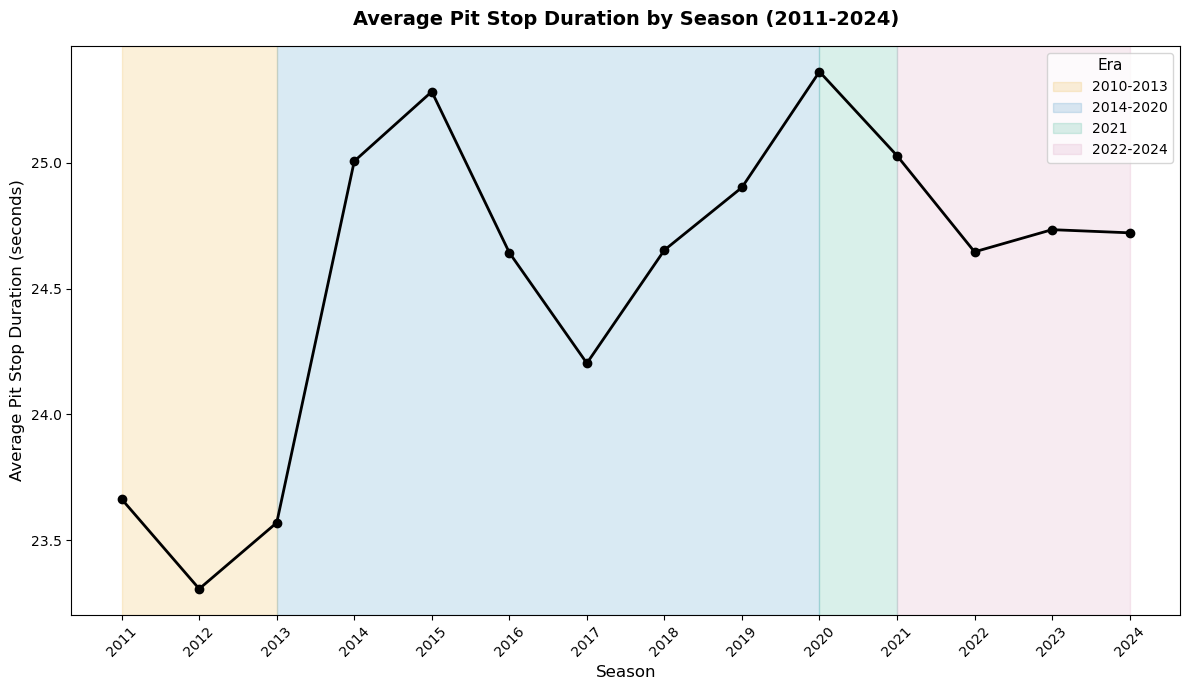

In [13]:
fig, ax = plt.subplots(figsize=(12, 7))

# Era shading in the background
era_spans = [
    (2011, 2013, '#E69F00', '2010-2013'),
    (2013, 2020, '#0072B2', '2014-2020'),
    (2020, 2021, '#009E73', '2021'),
    (2021, 2024, '#CC79A7', '2022-2024')
]

for start, end, color, label in era_spans:
    ax.axvspan(start, end, alpha=0.15, color=color, label=label)

# Average across all teams per season
season_avg = avg_pit_stop.groupby('year')['avg_pit_stop_duration'].mean().reset_index()

# Line chart
ax.plot(
    season_avg['year'],
    season_avg['avg_pit_stop_duration'],
    color='black',
    linewidth=2,
    marker='o',
    markersize=6,
    zorder=5
)

ax.set_title(
    'Average Pit Stop Duration by Season (2011-2024)',
    fontsize=14,
    fontweight='bold',
    pad=15
)
ax.set_xlabel('Season', fontsize=12)
ax.set_ylabel('Average Pit Stop Duration (seconds)', fontsize=12)

ax.set_xticks(season_avg['year'])
ax.set_xticklabels(season_avg['year'], rotation=45)

ax.legend(
    title='Era',
    title_fontsize=11,
    fontsize=10,
    loc='upper right'
)

plt.tight_layout()
plt.savefig('../visualizations/chart4_avg_pit_stop_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 4: Average Pit Stop Duration by Season (2011-2024)

### What this chart is asking
Has pit stop execution gotten faster or slower over time?
And did anything shift when the eras changed?

This is the first pure strategy chart in the project.
The driver is sitting completely still during a pit stop.
Every second on that timer belongs entirely to the team:
the crew, the equipment, the preparation, and the call
to bring the driver in at the right moment. No driver
skill involved.

### How to read this chart
The black line shows the average pit stop duration across
all teams in each season. Lower on the chart means faster.
The colored background bands show which era each season
belongs to so you can watch the trend and the era context
at the same time.

- Orange background: 2011-2013, Vettel and Red Bull
- Blue background: 2014-2020, Hamilton and Mercedes
- Green background: 2021, Verstappen vs Hamilton
- Pink background: 2022-2024, Verstappen dominance

### What this chart is telling us
A few things stand out immediately.

2011 and 2012 had the fastest pit stops of the early
era, dipping close to 23.3 seconds. Then times climbed
through the blue era, peaking sharply in 2015 and again
in 2020, which was the slowest year of the entire window.

Then something changed. The pink era from 2022 to 2024
shows the line sitting consistently lower and flatter
than most of the blue era. Pit stops got faster and
stayed faster. The sport as a whole got more efficient
in its most recent regulatory period.

### What this means for the stakeholder
If everyone is getting faster at roughly the same rate,
does pit stop speed still differentiate teams? The answer
is yes, and it actually matters more now. When the whole
field is fast, the gap between the fastest and slowest
crews becomes the differentiator. A mid-tier team that
invests in pit crew execution in the modern era is
competing in a sport where those seconds are increasingly
valued and increasingly contested.

### The 2020 spike
2020 stands out as the slowest year in the entire window.
This is worth noting but also worth being careful about.
2020 was the COVID season: a compressed calendar, unusual
circuits including two races at the same track, and
operational restrictions that affected how teams could
work. The spike likely reflects those disruptions as much
as any real change in crew execution.

### What we are measuring exactly
The duration is full pit lane transit time, from entry
to exit. That includes driving down the pit lane to the
box, the actual tire change which takes roughly 2-3
seconds for a top crew, and driving back out. The average
sits around 24 seconds because of this full transit
measurement, not just the tire change itself.

Pit lane length varies by circuit. Monaco has a much
shorter pit lane than Silverstone. So part of what the
average reflects in any given season is which circuits
were on the calendar, not just how fast the crews are.
Within a single season every team runs the same calendar
so team vs team comparison is fair. But comparing
absolute seconds across seasons may partly reflect
calendar changes rather than crew improvement alone.

### Caveats
- 2010 is excluded entirely. Pit stop data starts from
2011 in this dataset.
- 517 stops of 60 seconds or longer were excluded before
computing these averages. Those are race stoppage events,
not crew service. Including them would shift averages by
up to 225 seconds.
- This chart shows the league-wide average across all
teams combined. Individual team trends may look very
different. Chart 5 breaks this down by team vs
constructor standings directly.
- The 2020 spike likely reflects COVID season disruptions
as much as genuine crew execution changes.

### Future work
A circuit-level breakdown of avg pit stop duration would
control for pit lane length variation and isolate crew
execution more cleanly. By comparing each team at the
same circuit across years, calendar effects cancel out
and what remains is genuine crew improvement or decline.

## Chart 5: Avg Pit Stop Duration vs Constructor Season Points

**Purpose:** Do teams with faster pit stops finish higher in
the championship? This is the stakeholder-facing chart. It
directly addresses the budget question: should a mid-tier
constructor invest in pit crew execution?

**What it shows:** Every dot is one constructor in one
season. Left means faster pit stops. Higher means more
championship points. Color shows which era.

**Key finding:** No team with slow pit stops above 26
seconds scored significant constructor points in any era.
The highest scoring teams in every era cluster on the left
side of the chart, meaning faster execution. The
relationship is not perfectly linear but the direction is
clear: slow pit stops and high points do not coexist.

**Stakeholder takeaway:** Pit stop execution is not
sufficient on its own to win championships, the best
teams have fast pit crews AND fast cars. But slow pit
stop execution appears to be a ceiling. No team escaped
the bottom of the standings while also being slow in the
pit lane. For a mid-tier constructor, this suggests pit
crew investment is a necessary condition for competing
at the top, even if it is not the only condition.

**Important limitation:** This chart shows association
not causation. The teams with the fastest pit stops are
also the teams with the biggest budgets and the best
cars. You cannot isolate pit stop speed as the cause of
high points from this chart alone. What it does confirm
is that the two things travel together consistently
across all four eras.

**Caveats:**
- 2010 excluded, pit data starts 2011.
- 12 null rows dropped automatically by seaborn,
the 2010 team seasons with no pit stop data.
- Constructor points here are both drivers combined,
not official constructor standings which include
sprint points from 2021 onward.
- Cross-era point totals are not directly comparable
because the number of races and points available per
race changed across eras.

In [14]:
# Add a constructor_points column to team_season by adding points_high and points_low
team_season['constructor_points'] = team_season['points_high'] + team_season['points_low']

# Merge team_season with avg_pit_stop on constructorId and year
team_season_with_pit = pd.merge(
    team_season,
    avg_pit_stop[['constructorId', 'year', 'avg_pit_stop_duration']],
    on=['constructorId', 'year'],
    how='left'
)

team_season_with_pit['era'] = pd.cut(
    team_season_with_pit['year'],
    bins=[2009, 2013, 2020, 2021, 2024],
    labels=['2010-2013', '2014-2020', '2021', '2022-2024']
)

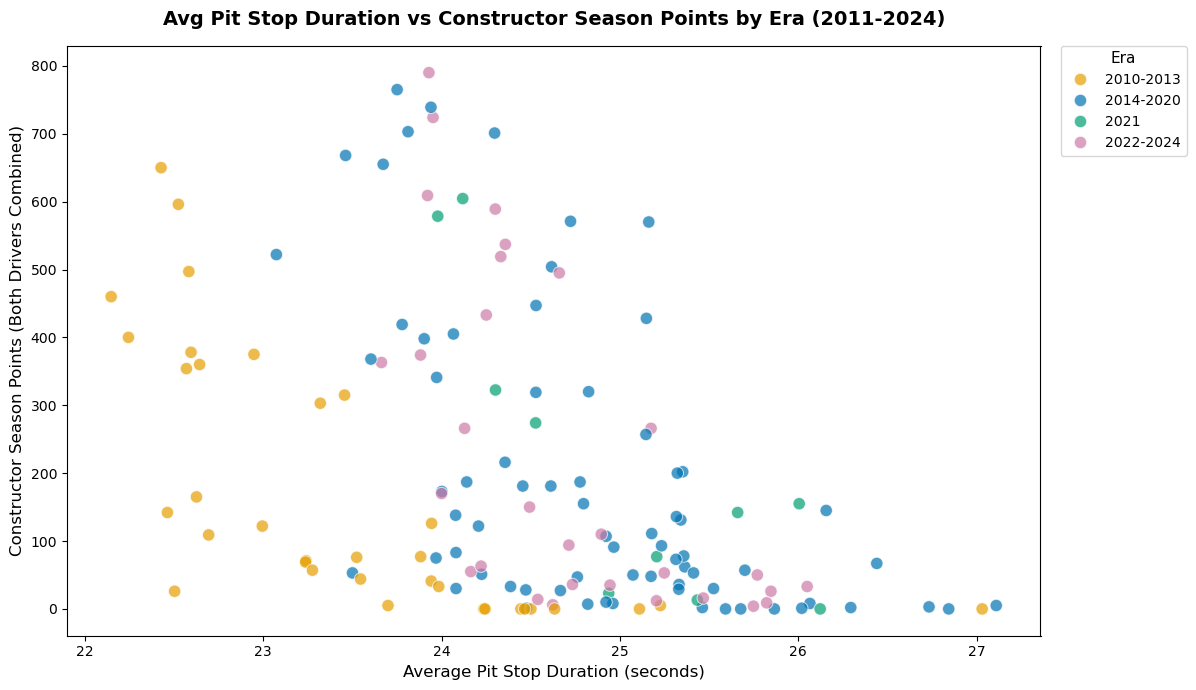

In [15]:
fig, ax = plt.subplots(figsize=(12, 7))

sns.scatterplot(
    data=team_season_with_pit,
    x='avg_pit_stop_duration',
    y='constructor_points',
    hue='era',
    hue_order=['2010-2013', '2014-2020', '2021', '2022-2024'],
    palette=era_palette,
    alpha=0.7,
    s=80,
    ax=ax
)
ax.set_title(
    'Avg Pit Stop Duration vs Constructor Season Points by Era (2011-2024)',
    fontsize=14,
    fontweight='bold',
    pad=15
)
ax.set_xlabel('Average Pit Stop Duration (seconds)', fontsize=12)
ax.set_ylabel('Constructor Season Points (Both Drivers Combined)', fontsize=12)

ax.legend(
    title='Era',
    title_fontsize=11,
    fontsize=10,
    loc='upper right',
    bbox_to_anchor=(1.15, 1),
    borderaxespad=0
)

plt.tight_layout()
plt.savefig('../visualizations/chart5_pit_stop_vs_constructor_points.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Chart 5: Avg Pit Stop Duration vs Constructor Season Points by Era (2011-2024)

### What this chart is asking
Do teams with faster pit stops finish higher in the
championship? This is the stakeholder-facing chart of
the entire project. It directly addresses the budget
question your stakeholder is trying to answer: should
a mid-tier constructor like Aston Martin or McLaren
invest in pit crew execution?

### How to read this chart
Every dot is one constructor in one season. There are
147 dots total, one per team per year from 2011 to 2024.

- Left side of the chart means faster pit stops.
Right side means slower.
- Higher up on the chart means more constructor
championship points that season.
- Color shows which era the dot belongs to.

If fast pit stops lead to more points, you would expect
to see dots clustering in the top left. If there is no
relationship, dots would be scattered randomly everywhere.

### What this chart is telling us
The pattern is clear even without a regression line.
No team with slow pit stops above 26 seconds scored
significant constructor points in any era. Every dot
sitting above 400 points is on the left half of the
chart, meaning faster execution. The highest scoring
teams in every era, the yellow dots from 2010-2013
sitting high and left, the blue dots from 2014-2020
peaking around 24 seconds, all cluster toward faster
pit stops.

The right side of the chart, slow pit stops above 26
seconds, is a graveyard of low point totals. Teams
sitting there are scoring near zero. No team escaped
the bottom of the standings while also being slow in
the pit lane.

### The 2010-2013 yellow cluster
The yellow dots are particularly interesting. They sit
further left than any other era, meaning the fastest
pit stops in the entire window happened in the early
Vettel years. Red Bull was not just winning with a
dominant car. Their pit crew execution was also at the
top of the sport. That combination is what a dominant
era looks like in the data.

### What this means for the stakeholder
Pit stop execution is not sufficient on its own to win
championships. The best teams have fast pit crews AND
fast cars AND strong drivers. You cannot buy a title
with pit crew speed alone.

But slow pit stop execution appears to be a hard
ceiling. No team in 14 seasons of data managed to
score big points while also being slow in the pit lane.
For a mid-tier constructor deciding where to invest,
this chart says: pit crew execution is a necessary
condition for competing at the top, even if it is not
the only condition. It will not guarantee you wins but
being slow in the pit lane will guarantee you stay near
the bottom.

### Important limitation: association not causation
This chart shows that fast pit stops and high points
travel together. It does not prove that fast pit stops
cause high points. The teams with the fastest pit stops
are also the teams with the biggest budgets, the best
cars, and the strongest drivers. All of those things
are correlated with each other. Isolating pit stop
speed as the sole driver of constructor performance
would require controlling for car quality, which is
explicitly out of scope for this project.

What this chart does confirm is that the association
is consistent across all four eras and all four
regulatory regimes. That consistency across 14 seasons
and two completely different technical regulations
makes the pattern harder to dismiss as coincidence.

### Caveats
- 2010 is excluded entirely. Pit stop data starts
from 2011. The 12 null rows from 2010 team seasons
were dropped automatically by seaborn when plotting.
- Constructor points here are both drivers combined
using grand prix points only. Official constructor
standings include sprint points from 2021 onward so
totals will not match official records for those years.
- Cross-era point totals are not directly comparable.
The number of races per season and points available
per race changed across eras. A 800 point season in
2020 is not the same as an 800 point season in 2012.
- Average pit stop duration includes full pit lane
transit, not just the tire change. Cross-season
comparisons partly reflect calendar changes as well
as crew execution improvement.
- This chart uses team-season grain. Individual race
level pit stop performance would give a more granular
picture and is noted as future work.

### Future work
A circuit-level breakdown controlling for pit lane
length variation would isolate crew execution more
cleanly. Adding a regression line per era would
formalize the direction and strength of the
association visible in the scatter. Both are noted
as natural extensions of this analysis.

## Additional EDA: Verification Checks

These are drill-down analyses that support and enrich the
five charts above. Not full visualizations, but numerical
checks that validate assumptions and surface additional
context for the research question.

### Check 1: DNF Rate by Era
Verifies the DNF rate claim used in Chart 1's caveats.
Confirms that DNF rates dropped sharply starting in 2021.

### Check 2: Grid-Finish Correlation by Circuit
Tests whether specific circuits skew Chart 1's overall
correlation. Some circuits make overtaking nearly
impossible while others produce chaos.

In [16]:
# Check 1: DNF rate by era
# Uses full results (not filtered), excludes never-started (W/F/E)
results_started = results[~results['positionText'].isin(['W','F','E'])].copy()
results_started['dnf'] = results_started['position'].isna()

dnf_by_era = results_started.groupby('era', observed=True).agg(
    total_starts=('dnf','size'),
    total_dnfs=('dnf','sum')
).reset_index()
dnf_by_era['dnf_rate_pct'] = (dnf_by_era['total_dnfs'] / dnf_by_era['total_starts'] * 100).round(1)
print(dnf_by_era.to_string(index=False))

      era  total_starts  total_dnfs  dnf_rate_pct
2010-2013          1797         305          17.0
2014-2020          2808         484          17.2
     2021           437          49          11.2
2022-2024          1352         159          11.8


**Finding:** DNF rates held steady at 17.0-17.2% for the
entire 2010-2020 period, then dropped sharply to 11.2-11.8%
starting in 2021. This confirms and refines the Chart 1
caveat: early eras are not just "slightly" underrepresented
in the finish-position scatter, they lose about 50% more
data to DNFs than the 2021-2024 era. The 2021 regulatory
transition and improved hybrid engine reliability likely
drive the drop.

In [17]:
circuits = pd.read_csv('../data/raw/circuits.csv')
circuits.columns

Index(['circuitId', 'circuitRef', 'name', 'location', 'country', 'lat', 'lng',
       'alt', 'url'],
      dtype='object')

In [18]:
# Check 2: grid-finish correlation by circuit
# Circuits table read from raw here for this verification check only.
# Not core to the modeling pipeline, so not added to notebook 01 cleaning.
# If circuit-level analysis becomes central in future work, add proper 
# cleaning step in notebook 01.
circuits = pd.read_csv('../data/raw/circuits.csv')

# Load races to get the circuitId for each race
races = pd.read_csv('../data/clean/races.csv')

# Two-hop merge: attach circuitId via races, then attach circuit name via circuits
finished_gridded_with_circuits = (
    results_finished_gridded
    .merge(races[['raceId', 'circuitId']], on='raceId')
    .merge(circuits[['circuitId', 'name']].rename(columns={'name':'circuit_name'}), on='circuitId')
)

# Correlation per circuit, minimum 5 races to be meaningful
circuit_corr = finished_gridded_with_circuits.groupby('circuit_name').apply(
    lambda x: pd.Series({
        'races_held': x['raceId'].nunique(),
        'corr_grid_finish': x['grid'].corr(x['position'])
    })
).reset_index()

circuit_corr = circuit_corr[circuit_corr['races_held'] >= 5].sort_values('corr_grid_finish', ascending=False)

print("Top 5 circuits where grid predicts finish MOST strongly:")
print(circuit_corr.head(5).to_string(index=False))
print()
print("Top 5 circuits where grid predicts finish LEAST strongly:")
print(circuit_corr.tail(5).to_string(index=False))

Top 5 circuits where grid predicts finish MOST strongly:
                  circuit_name  races_held  corr_grid_finish
Shanghai International Circuit        11.0          0.825177
  Autódromo Hermanos Rodríguez         9.0          0.814680
             Circuit de Monaco        14.0          0.812033
Circuit de Barcelona-Catalunya        15.0          0.797118
                Suzuka Circuit        13.0          0.789293

Top 5 circuits where grid predicts finish LEAST strongly:
                circuit_name  races_held  corr_grid_finish
              Hockenheimring         6.0          0.697868
Sepang International Circuit         8.0          0.697284
Circuit de Spa-Francorchamps        15.0          0.694288
           Baku City Circuit         8.0          0.682371
              Sochi Autodrom         8.0          0.672700


/var/folders/v2/9k8drrwj5h39kpr935vvx6j80000gn/T/ipykernel_92183/3543613458.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  circuit_corr = finished_gridded_with_circuits.groupby('circuit_name').apply(


**Finding:** Grid-finish correlation varies significantly
by circuit, ranging from 0.67 to 0.83. Shanghai, Mexico
City, and Monaco top the list, meaning starting position
essentially locks in the result at these tracks. Baku,
Sochi, and Spa show the weakest lock-in, meaning the race
itself matters more (Spa in particular has long straights
and DRS zones that enable overtaking).

**What this means for Chart 1:** The overall 0.75
correlation reported in Chart 1 is an average across a
real spread. Circuit type genuinely affects how much
grid position matters. This does not invalidate Chart 1
but adds nuance: some tracks amplify the "car dominates"
story while others give drivers more room to move.

**Noted as future work:** Weighting era comparisons by
circuit type, or splitting circuits into "high overtake"
vs "low overtake" categories, would produce a more
controlled comparison.